# 01 - Exploratory Data Analysis (EDA)

This notebook provides a structured EDA of the MovieLens raw data stored in `data/raw`.
The goal is to validate data quality, confirm table relationships, and analyze the tables in depth before feature engineering and modeling.


## EDA Scope and Workflow
1. [**Environment and Imports**](#1-environment-setup-and-imports): set deterministic and visualization configuration.
2. [**Data Loading**](#2-data-loading): load all `.dat` files defined in `file_map` from `data/raw`.
3. [**Global Data Quality**](#3-global-data-quality): evaluate missingness and duplicates across all tables.
4. [**Integrity Validation**](#4-integrity-validation): verify key cross-table relations (`movieID`, `tagID`).
5. [**Detailed EDA: `movie_actors`**](#5-detailed-eda-movie_actors): profile suspicious names, actor/movie distributions, and IMDb ranking quality.
6. [**Detailed EDA: `movie_countries`**](#6-detailed-eda-movie_countries): analyze country metadata quality and distribution patterns.
7. [**Detailed EDA: `movie_directors`**](#7-detailed-eda-movie_directors): analyze director metadata quality and director activity distributions.
8. [**Detailed EDA: `movie_genres`**](#8-detailed-eda-movie_genres): analyze genre metadata quality and genre assignment patterns.
9. [**Detailed EDA: `movie_locations`**](#9-detailed-eda-movie_locations): analyze location hierarchy quality and coverage patterns.
10. [**Detailed EDA: `tags`**](#10-detailed-eda-tags): analyze tag lookup quality and usage concentration across tagging tables.
11. [**Detailed EDA: `movie_tags`**](#11-detailed-eda-movie_tags): analyze movie-tag assignment quality and weight distribution.


## 1. Environment Setup and Imports
This section initializes the analysis environment:
- imports core libraries,
- sets random seed for reproducibility,
- configures plotting style and display options,
- resolves `PROJECT_ROOT` so notebook works from both project root and `notebooks/`.


In [57]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt  # visualization
import numpy as np  # numerical computing
import pandas as pd  # data manipulation
import seaborn as sns  # statistical plotting

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting style
PRIMARY_COLOR = "royalblue"
sns.set_theme(style="darkgrid")
plt.rcParams["patch.force_edgecolor"] = False

# Display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Make notebook runnable from project root and notebooks/
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


In [58]:
from src.eda.paths import get_file_map
from src.eda.data_loader import load_data_tables
from src.eda.data_quality import quality_report_global, dataframe_overview, integrity_report
from src.eda.utils import build_event_time

from src.eda.movie_actors import (
    suspicious_actor_report,
    actors_per_movie_report,
    movies_per_actor_report,
    ranking_imdb_order_report,
)

from src.eda.movie_countries import (
    suspicious_country_report,
    countries_per_movie_report,
    movies_per_country_report,
    country_coverage_report,
)

from src.eda.movie_directors import (
    suspicious_director_report,
    directors_per_movie_report,
    movies_per_director_report,
    director_coverage_report,
)

from src.eda.movie_genres import (
    suspicious_genre_report,
    genres_per_movie_report,
    movies_per_genre_report,
    genre_coverage_report,
)

from src.eda.movie_locations import (
    suspicious_location_report,
    rows_per_movie_location_report,
    location_depth_report,
    location_coverage_report,
)

from src.eda.tags import (
    suspicious_tag_report,
    tags_coverage_report,
    tag_usage_report,
)

from src.eda.movie_tags import (
    suspicious_movie_tags_report,
    movie_tags_coverage_report,
    tag_weight_report,
    tags_per_movie_report,
    movies_per_tag_report,
)


## 2. Data Loading


### Data Loading Notes
- Data source: `data/raw/*.dat`
- Loader: `load_data_tables(file_map)`
- Expected output: a dictionary of DataFrames keyed by table name.
- Validation in this step confirms all expected tables are available for EDA.


In [59]:
file_map = get_file_map(PROJECT_ROOT)
data = load_data_tables(file_map)

print(f'Loaded {len(data)} tables')
for name, df in data.items():
    print(f'{name:18s} -> shape={df.shape}')

Loaded 10 tables
movie_actors       -> shape=(231742, 4)
movie_countries    -> shape=(10197, 2)
movie_directors    -> shape=(10155, 3)
movie_genres       -> shape=(20809, 2)
movie_locations    -> shape=(49167, 5)
movie_tags         -> shape=(51795, 3)
movies             -> shape=(10197, 21)
tags               -> shape=(13222, 2)
user_ratedmovies   -> shape=(855598, 9)
user_taggedmovies  -> shape=(47957, 9)


## 3. Global Data Quality


### Goal
Create a global quality snapshot for all loaded tables, focusing on missing values and duplicate rows.


In [60]:
quality_df = quality_report_global(data)
display(quality_df)

,table,rows,cols,missing_cells,duplicate_rows
0,movie_actors,231742,4,5,0
1,movie_countries,10197,2,8,0
2,movie_directors,10155,3,0,0
3,movie_genres,20809,2,0,0
4,movie_locations,49167,5,37308,0
5,movie_tags,51795,3,0,0
6,movies,10197,21,492,0
7,tags,13222,2,0,0
8,user_ratedmovies,855598,9,0,0
9,user_taggedmovies,47957,9,0,0


### Interpretation: Global Data Quality
- The dataset contains 10 tables. No table has duplicated rows at full-row level.
- The highest missingness appears in `movie_locations` with 37,308 missing cells (mostly optional location fields).
- `movies` has 492 missing cells, while `movie_actors` has only 5 missing cells and `movie_countries` has 8.
- `user_ratedmovies` (855,598 rows) and `user_taggedmovies` (47,957 rows) are complete at cell level for available columns.
- Overall conclusion: data quality is strong, with missingness concentrated in location metadata rather than interaction logs.


## 4. Integrity Validation

### Goal
Validate cross-table consistency before any feature engineering or join-heavy analysis.


In [61]:
integrity_df = integrity_report(data)
display(integrity_df)

,check,violations
0,movie_actors.movieID in movies.id,0
1,movie_countries.movieID in movies.id,0
2,movie_directors.movieID in movies.id,0
3,user_ratedmovies.movieID in movies.id,0
4,movie_genres.movieID in movies.id,0
5,movie_locations.movieID in movies.id,0
6,user_taggedmovies.movieID in movies.id,0
7,user_taggedmovies.tagID in tags.id,0
8,movie_tags.movieID in movies.id,0
9,movie_tags.tagID in tags.id,0


### Interpretation: Integrity Checks
- All 10 referential checks returned **0 violations**.
- Every `movieID` in relationship tables maps to `movies.id`.
- Every `tagID` in tagging tables maps to `tags.id`.
- Conclusion: key cross-table joins are fully consistent in `data/raw`, so no FK-based row filtering is required at this stage.


## 5. Detailed EDA: `movie_actors`
### Overview of `movie_actors`


### Goal
Perform a table-specific EDA for `movie_actors` to quantify name quality, cast-size patterns, and rank reliability.


In [62]:
movie_actors_df = data["movie_actors"]

movie_actors_overview = dataframe_overview(movie_actors_df)
display(movie_actors_overview)

,column,dtype,type_group,missing_count,missing_pct,n_unique,mean,std,min,max
0,actorName,object,non-numeric,5,0.0,95241,NaN,NaN,NaN,NaN
1,movieID,int64,id-like,0,0.0,10174,NaN,NaN,NaN,NaN
2,actorID,object,non-numeric,0,0.0,95321,NaN,NaN,NaN,NaN
3,ranking,int64,numeric,0,0.0,220,18.522732,18.368837,1.0,220.0


### Interpretation: Overview of `movie_actors`
- `movie_actors` contains 231,742 rows and 4 columns (`movieID`, `actorID`, `actorName`, `ranking`).
- Missingness is minimal (5 cells total), and there are no full-row duplicates.
- Pair-level duplicates (`movieID + actorID`) are also 0, so actor-film links are unique.
- The table is structurally ready for feature engineering with only minor name-quality cleanup.


### Suspicious Actors in `movie_actors`


### Goal
Identify potentially invalid actor names and define a cleaning/flagging policy.


In [63]:
suspicious_actor = suspicious_actor_report(movie_actors_df)

print("Suspicious Actors Report Summary: ")
display(suspicious_actor["summary"])

print("\n Suspicious Actors Report Details:")
display(suspicious_actor["suspicious_rows"])

Suspicious Actors Report Summary: 


,metric,value
0,rows_total,231742
1,missing_actor_name,5
2,empty_or_whitespace_actor_name,0
3,very_short_actor_name_len_1_2,14
4,numeric_only_actor_name,0
5,suspicious_rows_total,19



 Suspicious Actors Report Details:


,movieID,actorID,actorName,ranking,reason
12722,532,not_applicable,NaN,26,missing
44595,2175,770735397,BG,3,very_short
65402,3142,u2,U2,1,very_short
69891,3338,jr,Jr,9,very_short
105395,4875,gq,GQ,6,very_short
113034,5218,not_applicable,NaN,15,missing
123252,5710,not_applicable,NaN,7,missing
126895,5911,x,X,14,very_short
127397,5941,gq,GQ,5,very_short
138845,6454,mi,Mi,60,very_short


### Interpretation: Suspicious Actors
- Total flagged rows: **19 / 231,742** (0.0082%).
- Breakdown: 5 missing names, 14 very short names, 0 empty strings, 0 numeric-only names.
- This is a very small fraction; treat these as targeted cleanup cases rather than a systemic issue.
- Practical policy: remove clearly invalid records, keep plausible short aliases with a quality flag if needed.


### Actors per movie


### Goal
Measure cast-size distribution per movie and detect heavy-tail behavior.


In [64]:
actors_per_movie = actors_per_movie_report(movie_actors_df)

print("Actors per movie Summary: ")
display(actors_per_movie["summary"])

Actors per movie Summary: 


,metric,value
0,movies_with_cast,10174.000
1,mean,22.778
2,median,17.000
3,p90,46.000
4,p95,56.000
5,p99,82.000
6,max,220.000


### Interpretation: Actors per Movie (Summary)
- Movies with cast info: **10,174 / 10,197** movies (99.77% coverage).
- Cast size statistics: mean 22.78, median 17, p90 46, p99 82, max 220.
- The gap between median (17) and p99 (82) confirms a strong long-tail pattern.
- This supports using robust statistics or capped features in later modeling.


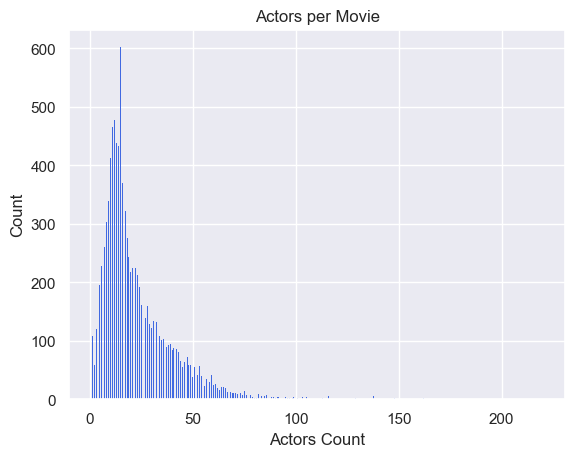

In [65]:
ACTORS_PER_MOVIE_BINS = int(np.sqrt(len(movie_actors_df)))

plt.hist(
    actors_per_movie["distribution"],
    bins=ACTORS_PER_MOVIE_BINS,
    color=PRIMARY_COLOR,
)
plt.title("Actors per Movie")
plt.xlabel("Actors Count")
plt.ylabel("Count")
plt.show()


### Interpretation: Actors per Movie (Histogram)
- The histogram is right-skewed: most movies have relatively small-to-medium casts.
- A long tail extends to very large casts (up to 220), which is expected in real film metadata.
- This shape is data-realistic, not an error signal.
- For reporting, emphasize that extreme cast sizes are rare but present.


In [66]:
print("Most actors in movie: ")
display(actors_per_movie["top_movies"])

Most actors in movie: 


,actors_per_movie
movieID,
3246,220
54190,190
5686,188
785,178
7143,163
4719,162
60389,162
7312,156
4008,149


### Interpretation: Top Movies by Cast Size
- Top cast sizes are high (e.g., movieID 3246: 220 actors; 54190: 190; 5686: 188).
- Since `movieID + actorID` duplicates are zero, these extremes are not caused by duplicate links.
- Interpretation: these are likely genuinely large-cast productions.
- Keep them in the data; if needed, cap only downstream features, not source records.


### Movies per actor


### Goal
Measure actor activity across movies and identify upper-tail prolific actors.


In [67]:
movies_per_actor = movies_per_actor_report(movie_actors_df)

print("Movies per actor Summary: ")
display(movies_per_actor["summary"])

Movies per actor Summary: 


,metric,value
0,actors_total,95321.000
1,mean,2.431
2,median,1.000
3,p90,5.000
4,p95,8.000
5,p99,20.000
6,max,72.000


### Interpretation: Movies per Actor (Summary)
- Total actors: 95,321.
- Distribution: mean 2.43, median 1, p90 5, p99 20, max 72.
- Most actors appear in a single movie, while a small minority appears in many titles.
- This is a classic sparse participation pattern and useful for actor-experience features.


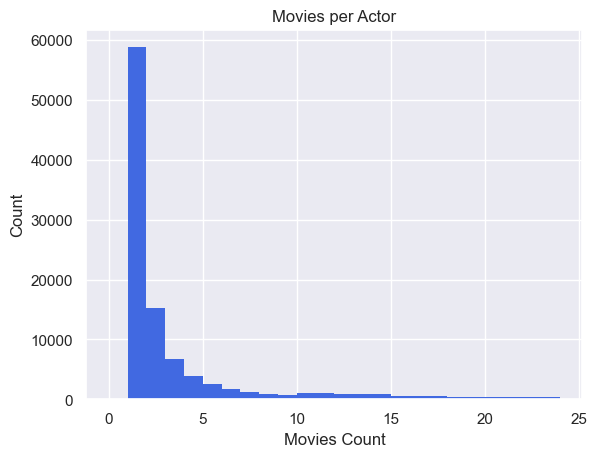

In [68]:
MOVIES_PER_ACTOR_BINS = np.r_[
    np.arange(0, 11, 1),
    np.arange(12, 26, 3),
]

plt.hist(
    movies_per_actor["distribution"],
    bins=MOVIES_PER_ACTOR_BINS,
    color=PRIMARY_COLOR,
)
plt.title("Movies per Actor")
plt.xlabel("Movies Count")
plt.ylabel("Count")
plt.show()


### Interpretation: Movies per Actor (Histogram)
- The histogram is strongly concentrated at low counts (especially 1 movie per actor).
- Frequency drops quickly as movie count increases, with a long but thin tail.
- Uneven bins are appropriate here because resolution is most important near small counts.
- This confirms that popularity/experience features will be highly skewed.


In [69]:
print("The most movies in actor's career: ")
display(movies_per_actor["top_actors"])

The most movies in actor's career: 


,movies_per_actor,actorName
actorID,,
samuel_l_jackson,72,Samuel L. Jackson
robert_de_niro,70,Robert De Niro
steve_buscemi,66,Steve Buscemi
christopher_walken,64,Christopher Walken
robert_duvall,62,Robert Duvall
robin_williams,60,Robin Williams
donald_sutherland,59,Donald Sutherland
harvey_keitel,58,Harvey Keitel
michael_caine,58,Michael Caine


### Interpretation: Top Actors by Movie Count
- Highest observed counts include: Samuel L. Jackson (72), Robert De Niro (70), Steve Buscemi (66), Christopher Walken (64), Robert Duvall (62).
- These values are plausible for prolific actors and support data credibility.
- No immediate evidence of synthetic inflation from duplicate actor-movie links.
- These records are good candidates for upper-tail analysis in feature engineering.


### Actors rankings


### Goal
Assess whether IMDb cast-order ranking can be safely used for feature construction.


In [70]:
ranking_imdb_order = ranking_imdb_order_report(movie_actors_df)

print("Rankings summary: ")
display(ranking_imdb_order["summary"])

Rankings summary: 


,metric,value
0,rows_total,231742
1,missing_ranking,0
2,non_positive_ranking,0
3,non_integer_ranking,0
4,duplicate_ranking_within_movie_rows,4142
5,movies_with_non_contiguous_ranking,0


### Interpretation: Ranking Quality (IMDb Order)
- `ranking` quality is strong: missing = 0, non-positive = 0, non-integer = 0.
- Duplicate rank rows within movie: 4,142 rows (same `movieID` and rank assigned to multiple rows).
- Non-contiguous movie rankings: 0 movies.
- Conclusion: rank sequences are complete and start correctly; only within-movie tie/conflict cases need review.


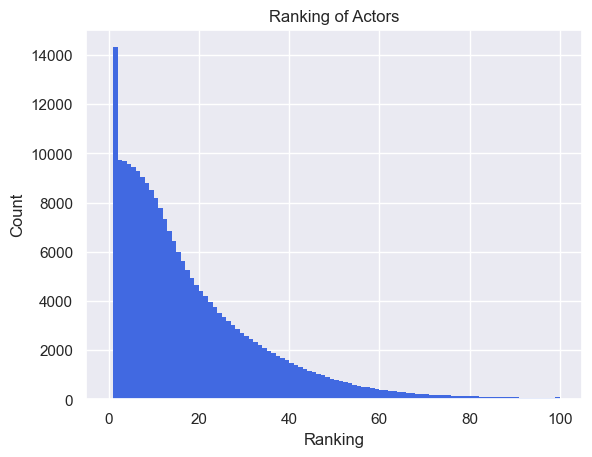

In [71]:
RANKING_BINS = np.arange(0, 101, 1).tolist()

plt.hist(
    ranking_imdb_order["distribution"],
    bins=RANKING_BINS,
    color=PRIMARY_COLOR,
)
plt.title("Ranking of Actors")
plt.xlabel("Ranking")
plt.ylabel("Count")
plt.show()


### Interpretation: Ranking Histogram
- Ranking ranges from 1 to 220, with median 13 and p90 41 (p99 88).
- Mass is concentrated at low rank values, consistent with IMDb cast ordering.
- The right tail reflects movies with larger casts.
- The distribution is suitable for either raw use or bucket-based transformation.


In [72]:
print("Duplicate rankings rows: ")
display(ranking_imdb_order["duplicate_ranking_rows"])

Duplicate rankings rows: 


,movieID,actorID,actorName,ranking,ranking_num
992,33,_0028342,Freddy Andreiuci,1,1
993,33,_0423666,Balinder Johal,1,1
994,33,_0767205,Ron Sauvé,1,1
995,33,craig_sheffer,Craig Sheffer,1,1
996,33,elizabeth_mcgovern,Elizabeth McGovern,1,1
...,...,...,...,...,...
231441,64959,_0381960,Walter Hewel,1,1
231442,64959,_0383183,Konstantin Hierl,1,1
231443,64959,adolf_hitler,Adolf Hitler,1,1
231444,64959,josef_goebbels,Josef Goebbels,1,1


### Interpretation: Duplicate Ranking Rows
- Duplicate rank assignments exist (4,142 rows flagged at row level).
- This means some movies contain multiple rows sharing the same rank value.
- It is a local ordering conflict, not a missingness problem.
- Recommended next step: keep rows but add a conflict flag, or apply deterministic tie-handling in feature engineering.


In [73]:
print("Non contiguous movies rankings: ")
display(ranking_imdb_order["non_contiguous_movies"])

Non contiguous movies rankings: 


,movieID


### Interpretation: Non-Contiguous Rankings
- Non-contiguous ranking movies count is **0**.
- All movie-level rank sequences are contiguous and start from rank 1 after numeric parsing.
- This is a strong quality signal for using rank-derived features.
- No additional repair is needed for sequence continuity.


### Section 5 Summary
- `movie_actors` is high-quality overall (231,742 rows, no duplicate `movieID + actorID` pairs).
- Data quality issues are limited and local (19 suspicious-name rows, plus rank-duplication conflicts in some movies).
- Distribution patterns are strongly long-tail for both cast size per movie and movies per actor.
- IMDb ranking is structurally reliable (no missing/non-positive/non-integer values; contiguous sequences).
- Next step in feature engineering: add quality flags (name/rank conflicts), and use robust encoding for long-tail frequency features.


## 6. Detailed EDA: `movie_countries`


### Goal
Assess country metadata quality, movie-level coverage, and country distribution concentration.


In [74]:
movie_countries_df = data["movie_countries"]
movies_df = data["movies"]

movie_countries_overview = dataframe_overview(movie_countries_df)
display(movie_countries_overview)


,column,dtype,type_group,missing_count,missing_pct,n_unique,mean,std,min,max
0,country,object,non-numeric,8,0.0008,71,None,None,None,None
1,movieID,int64,id-like,0,0.0000,10197,None,None,None,None


### Interpretation: Overview of `movie_countries`
- `movie_countries` is compact and clean: 10,197 rows, 2 columns, and no duplicate rows.
- Key quality issue is minimal (8 missing `country` values), with no duplicate `movieID + country` pairs.
- Structural conclusion: the table is reliable for country-based feature construction.


In [75]:
country_coverage = country_coverage_report(movie_countries_df, movies_df)
print("Country coverage summary:")
display(country_coverage)


Country coverage summary:


,metric,value
0,movies_total,10197.0
1,movies_with_country,10197.0
2,coverage_pct,100.0


### Interpretation: Country Coverage
- Coverage is complete at movie level: **10,197 / 10,197 (100.0%)** movies have a country record.
- This removes the need for join-time fallback logic when building movie-level country features.


### Suspicious Countries


In [76]:
suspicious_country = suspicious_country_report(movie_countries_df)

print("Suspicious Country Report Summary:")
display(suspicious_country["summary"])

print("\nSuspicious Country Report Details:")
display(suspicious_country["suspicious_rows"])


Suspicious Country Report Summary:


,metric,value
0,rows_total,10197
1,missing_country,8
2,empty_or_whitespace_country,0
3,numeric_only_country,0
4,one_character_country,0
5,suspicious_rows_total,8



Suspicious Country Report Details:


,movieID,country,reason
899,985,NaN,missing
1571,1752,NaN,missing
2622,2855,NaN,missing
3624,3915,NaN,missing
6145,6520,NaN,missing
7566,8579,NaN,missing
9046,43708,NaN,missing
9538,53883,NaN,missing


### Interpretation: Suspicious Countries
- Flagged rows: **8**, all due to missing `country` values.
- No empty-string, numeric-only, or one-character noise values were detected.
- Data-cleaning action: handle the 8 missing values explicitly (drop or assign `Unknown`).


### Countries per movie


In [77]:
countries_per_movie = countries_per_movie_report(movie_countries_df)

print("Countries per movie summary:")
display(countries_per_movie["summary"])


Countries per movie summary:


,metric,value
0,movies_with_country,10197.0
1,mean,1.0
2,median,1.0
3,p90,1.0
4,p95,1.0
5,p99,1.0
6,max,1.0


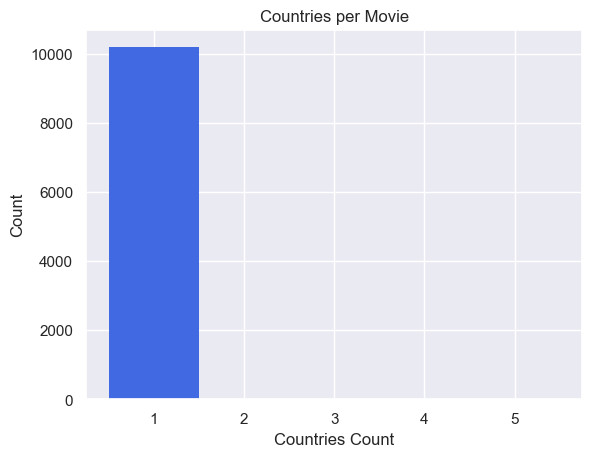

In [78]:
COUNTRIES_PER_MOVIE_BINS = np.arange(0.5, 5.6, 1.0).tolist()

plt.hist(
    countries_per_movie["distribution"],
    bins=COUNTRIES_PER_MOVIE_BINS,
    color=PRIMARY_COLOR,
)
plt.title("Countries per Movie")
plt.xlabel("Countries Count")
plt.ylabel("Count")
plt.show()


### Interpretation: Countries per Movie
- The distribution is fully concentrated at 1 (mean=1.0, median=1.0, p99=1.0, max=1).
- Interpretation: each movie has exactly one country label in this dataset.
- Modeling impact: encode as a single categorical feature, not multi-label country lists.


### Movies per country


In [79]:
movies_per_country = movies_per_country_report(movie_countries_df)

print("Movies per country summary:")
display(movies_per_country["summary"])

print("Top countries by movie count:")
display(movies_per_country["top_countries"])


Movies per country summary:


,metric,value
0,countries_total,71.000
1,mean,143.507
2,median,8.000
3,p90,120.000
4,p95,219.000
5,p99,2759.800
6,max,6831.000


Top countries by movie count:


,movies_per_country
country,
USA,6831
UK,1015
France,577
Canada,233
Italy,205
Japan,192
Germany,180
Australia,120
Spain,105


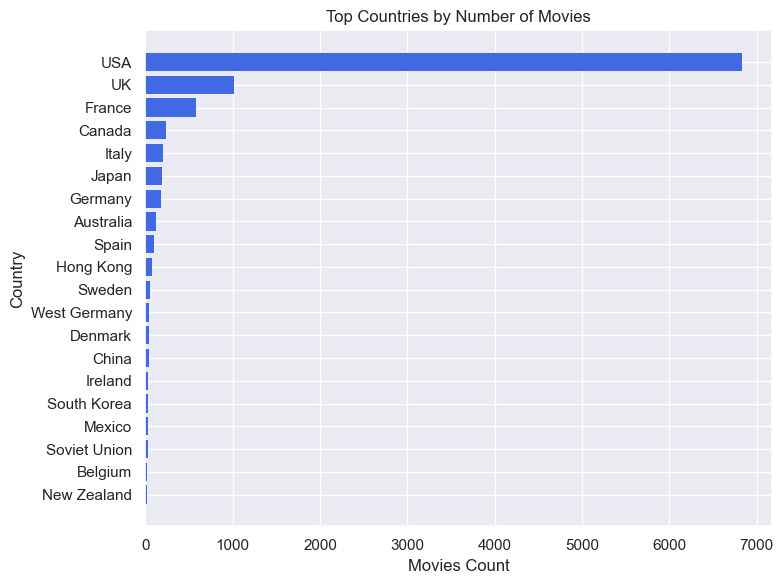

In [80]:
TOP_COUNTRIES_PLOT_N = 20

plot_df = movies_per_country["top_countries"].head(TOP_COUNTRIES_PLOT_N).sort_values("movies_per_country")
plt.figure(figsize=(8, 6))
plt.barh(plot_df.index.astype(str), plot_df["movies_per_country"], color=PRIMARY_COLOR)
plt.title("Top Countries by Number of Movies")
plt.xlabel("Movies Count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


### Interpretation: Movies per Country
- Country frequency is highly skewed: 71 countries total, median 8 movies, max 6,831.
- The head is dominated by USA (6,831), then UK (1,015) and France (577).
- Modeling action: keep top countries and group low-frequency countries into `Other` to reduce sparsity.


### Section 6 Summary
- `movie_countries` is production-usable with only 8 missing country values to resolve.
- Country assignment is one-to-one per movie, enabling straightforward encoding.
- Distribution imbalance should be addressed via rare-country grouping in feature engineering.


## 7. Detailed EDA: `movie_directors`


### Goal
Assess director metadata quality, movie-level coverage, and director activity concentration.


In [81]:
movie_directors_df = data["movie_directors"]
movies_df = data["movies"]

movie_directors_overview = dataframe_overview(movie_directors_df)
display(movie_directors_overview)


,column,dtype,type_group,missing_count,missing_pct,n_unique,mean,std,min,max
0,movieID,int64,id-like,0,0.0,10155,None,None,None,None
1,directorID,object,non-numeric,0,0.0,4060,None,None,None,None
2,directorName,object,non-numeric,0,0.0,4053,None,None,None,None


### Interpretation: Overview of `movie_directors`
- `movie_directors` has 10,155 rows and 3 columns (`movieID`, `directorID`, `directorName`).
- There are no missing values and no duplicate rows.
- Pair-level duplicates (`movieID + directorID`) are 0, indicating unique movie-director links.


In [82]:
director_coverage = director_coverage_report(movie_directors_df, movies_df)
print("Director coverage summary:")
display(director_coverage)


Director coverage summary:


,metric,value
0,movies_total,10197.000
1,movies_with_director,10155.000
2,coverage_pct,99.588


### Interpretation: Director Coverage
- Coverage is **99.588%** (`10,155 / 10,197` movies have at least one director assignment).
- Missing director mapping is limited to 42 movies, which is low but non-zero.
- For modeling, define fallback handling for those unmapped movies (`Unknown` or exclusion).


### Suspicious Directors


In [83]:
suspicious_director = suspicious_director_report(movie_directors_df)

print("Suspicious Director Report Summary:")
display(suspicious_director["summary"])

print("\nSuspicious Director Report Details:")
display(suspicious_director["suspicious_rows"])


Suspicious Director Report Summary:


,metric,value
0,rows_total,10155
1,missing_director_name,0
2,empty_or_whitespace_director_name,0
3,very_short_director_name_len_1_2,0
4,numeric_only_director_name,0
5,suspicious_rows_total,0



Suspicious Director Report Details:


,movieID,directorID,directorName,reason


### Interpretation: Suspicious Directors
- Suspicious rows total is **0**: no missing, empty, very short, or numeric-only director names.
- This is a high-confidence metadata field suitable for downstream encoding and aggregation.


### Directors per movie


In [84]:
directors_per_movie = directors_per_movie_report(movie_directors_df)

print("Directors per movie summary:")
display(directors_per_movie["summary"])


Directors per movie summary:


,metric,value
0,movies_with_director,10155.0
1,mean,1.0
2,median,1.0
3,p90,1.0
4,p95,1.0
5,p99,1.0
6,max,1.0


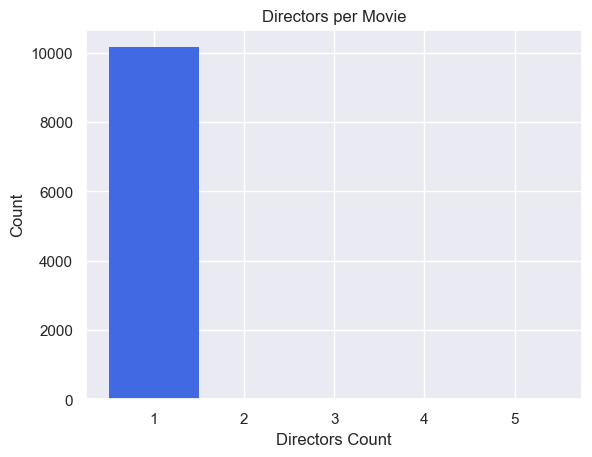

In [85]:
DIRECTORS_PER_MOVIE_BINS = np.arange(0.5, 5.6, 1.0).tolist()

plt.hist(
    directors_per_movie["distribution"],
    bins=DIRECTORS_PER_MOVIE_BINS,
    color=PRIMARY_COLOR,
)
plt.title("Directors per Movie")
plt.xlabel("Directors Count")
plt.ylabel("Count")
plt.show()


### Interpretation: Directors per Movie
- Distribution is concentrated at 1 (mean=1.0, median=1.0, p99=1.0, max=1).
- Each mapped movie has exactly one director in this dataset.
- This supports single-label director features without multi-director resolution logic.


### Movies per director


In [86]:
movies_per_director = movies_per_director_report(movie_directors_df)

print("Movies per director summary:")
display(movies_per_director["summary"])

print("Top directors by movie count:")
display(movies_per_director["top_directors"])


Movies per director summary:


,metric,value
0,directors_total,4060.000
1,mean,2.501
2,median,1.000
3,p90,6.000
4,p95,8.000
5,p99,15.000
6,max,48.000


Top directors by movie count:


,movies_per_director,directorName
directorID,,
alfred_hitchcock,48,Alfred Hitchcock
woody_allen,40,Woody Allen
clint_eastwood,32,Clint Eastwood
akira_kurosawa,30,Akira Kurosawa
martin_scorsese,30,Martin Scorsese
steven_spielberg,29,Steven Spielberg
sidney_lumet,27,Sidney Lumet
john_ford,27,John Ford
billy_wilder,24,Billy Wilder


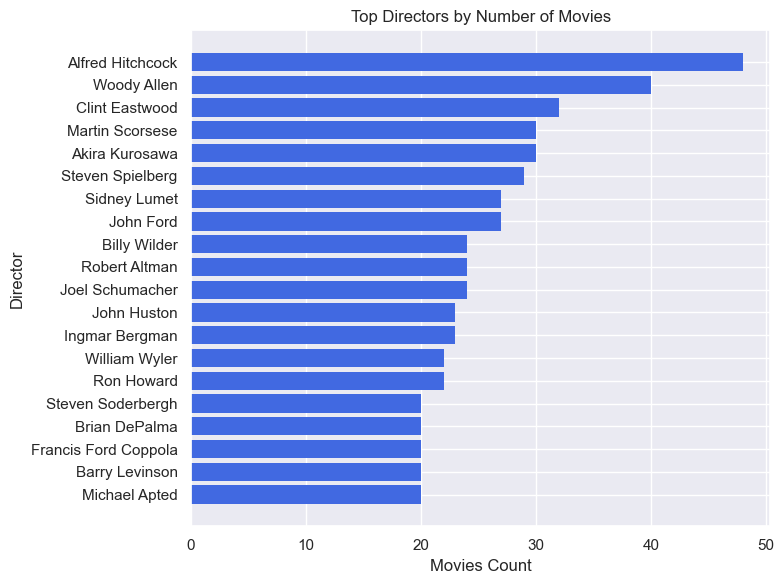

In [87]:
TOP_DIRECTORS_PLOT_N = 20

plot_df = movies_per_director["top_directors"].head(TOP_DIRECTORS_PLOT_N).sort_values("movies_per_director")
plt.figure(figsize=(8, 6))
plt.barh(plot_df["directorName"], plot_df["movies_per_director"], color=PRIMARY_COLOR)
plt.title("Top Directors by Number of Movies")
plt.xlabel("Movies Count")
plt.ylabel("Director")
plt.tight_layout()
plt.show()


### Interpretation: Movies per Director
- There are 4,060 unique directors. The distribution is long-tail (median=1, p90=6, p99=15, max=48).
- The most frequent directors include Alfred Hitchcock (48) and Woody Allen (40), which is domain-plausible.
- For modeling, direct one-hot for all directors may be sparse; consider top-k + `Other` encoding.


### Section 7 Summary
- `movie_directors` is high-quality (no missing/no duplicates in core fields).
- Coverage is strong but not complete (42 movies without director mapping).
- Director activity is highly skewed, so rare-director grouping is recommended in feature engineering.


## 8. Detailed EDA: `movie_genres`


### Goal
Assess genre metadata quality, movie-level genre coverage, and genre frequency concentration.


In [88]:
movie_genres_df = data["movie_genres"]
movies_df = data["movies"]

movie_genres_overview = dataframe_overview(movie_genres_df)
display(movie_genres_overview)


,column,dtype,type_group,missing_count,missing_pct,n_unique,mean,std,min,max
0,movieID,int64,id-like,0,0.0,10197,None,None,None,None
1,genre,object,non-numeric,0,0.0,20,None,None,None,None


### Interpretation: Overview of `movie_genres`
- `movie_genres` has 20,809 rows and 2 columns (`movieID`, `genre`).
- There are no missing values and no duplicate rows.
- Pair-level duplicates (`movieID + genre`) are 0, so genre assignments are unique per movie.


In [89]:
genre_coverage = genre_coverage_report(movie_genres_df, movies_df)
print("Genre coverage summary:")
display(genre_coverage)


Genre coverage summary:


,metric,value
0,movies_total,10197.0
1,movies_with_genre,10197.0
2,coverage_pct,100.0


### Interpretation: Genre Coverage
- Coverage is **100.0%** (`10,197 / 10,197` movies have at least one genre assignment).
- This enables fully consistent genre feature generation for all movies.


### Suspicious Genres


In [90]:
suspicious_genre = suspicious_genre_report(movie_genres_df)

print("Suspicious Genre Report Summary:")
display(suspicious_genre["summary"])

print("\nSuspicious Genre Report Details:")
display(suspicious_genre["suspicious_rows"])


Suspicious Genre Report Summary:


,metric,value
0,rows_total,20809
1,missing_genre,0
2,empty_or_whitespace_genre,0
3,one_character_genre,0
4,numeric_only_genre,0
5,suspicious_rows_total,0



Suspicious Genre Report Details:


,movieID,genre,reason


### Interpretation: Suspicious Genres
- Suspicious rows total is **0**: no missing, empty, one-character, or numeric-only genre values.
- Genre labels are clean and ready for direct categorical encoding.


### Genres per movie


In [91]:
genres_per_movie = genres_per_movie_report(movie_genres_df)

print("Genres per movie summary:")
display(genres_per_movie["summary"])


Genres per movie summary:


,metric,value
0,movies_with_genre,10197.000
1,mean,2.041
2,median,2.000
3,p90,3.000
4,p95,4.000
5,p99,5.000
6,max,8.000


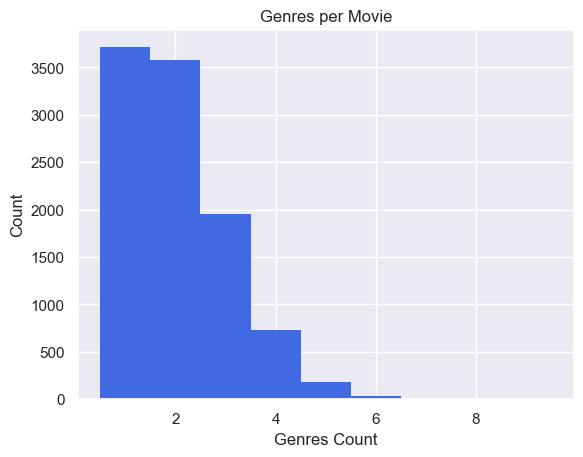

In [92]:
GENRES_PER_MOVIE_BINS = np.arange(0.5, 9.6, 1.0).tolist()

plt.hist(
    genres_per_movie["distribution"],
    bins=GENRES_PER_MOVIE_BINS,
    color=PRIMARY_COLOR,
)
plt.title("Genres per Movie")
plt.xlabel("Genres Count")
plt.ylabel("Count")
plt.show()


### Interpretation: Genres per Movie
- Movies are multi-genre: mean=2.041, median=2, p90=3, p99=5, max=8.
- This is not a single-label taxonomy, so multi-label genre encoding is appropriate.


### Movies per genre


In [93]:
movies_per_genre = movies_per_genre_report(movie_genres_df)

print("Movies per genre summary:")
display(movies_per_genre["summary"])

print("Top genres by movie count:")
display(movies_per_genre["top_genres"])


Movies per genre summary:


,metric,value
0,genres_total,20.00
1,mean,1040.45
2,median,527.00
3,p90,1854.20
4,p95,3641.50
5,p99,4789.10
6,max,5076.00


Top genres by movie count:


,movies_per_genre
genre,
Drama,5076
Comedy,3566
Thriller,1664
Romance,1644
Action,1445
Crime,1086
Adventure,1003
Horror,978
Sci-Fi,740


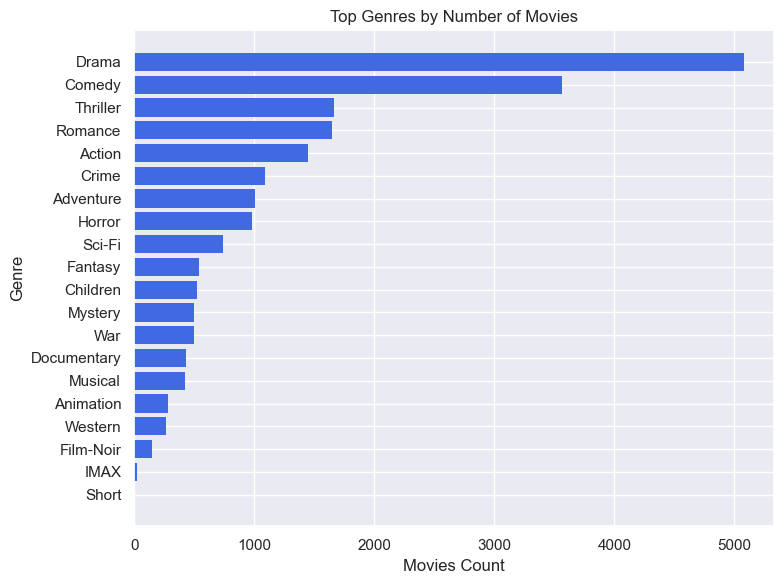

In [94]:
TOP_GENRES_PLOT_N = 20

plot_df = movies_per_genre["top_genres"].head(TOP_GENRES_PLOT_N).sort_values("movies_per_genre")
plt.figure(figsize=(8, 6))
plt.barh(plot_df.index.astype(str), plot_df["movies_per_genre"], color=PRIMARY_COLOR)
plt.title("Top Genres by Number of Movies")
plt.xlabel("Movies Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


### Interpretation: Movies per Genre
- There are 20 genres. Distribution is head-heavy: Drama (5,076) and Comedy (3,566) dominate.
- Mid/low-frequency genres remain informative but may need smoothing/regularization in models.
- Genre frequency imbalance should be considered when building popularity-based features.


### Section 8 Summary
- `movie_genres` is complete and clean (no missing/no duplicates; full movie coverage).
- Movies are multi-genre on average (~2 genres per movie), so multi-label representation is required.
- Genre frequencies are imbalanced, with strong concentration in a few dominant genres.


## 9. Detailed EDA: `movie_locations`


### Goal
Assess location hierarchy completeness, row density per movie, and location metadata quality.


In [95]:
movie_locations_df = data["movie_locations"]
movies_df = data["movies"]

movie_locations_overview = dataframe_overview(movie_locations_df)
display(movie_locations_overview)


,column,dtype,type_group,missing_count,missing_pct,n_unique,mean,std,min,max
0,location4,object,non-numeric,26555,0.5401,10063,None,None,None,None
1,location3,object,non-numeric,6856,0.1394,5945,None,None,None,None
2,location2,object,non-numeric,2629,0.0535,1385,None,None,None,None
3,location1,object,non-numeric,1268,0.0258,186,None,None,None,None
4,movieID,int64,id-like,0,0.0000,10197,None,None,None,None


### Interpretation: Overview of `movie_locations`
- `movie_locations` contains 49,167 rows and 5 columns (`movieID`, `location1`-`location4`).
- No duplicate rows and no duplicate key tuples (`movieID + location1..4`).
- Missingness increases with depth (`location4` is sparsest), which is expected for hierarchical location data.


In [96]:
location_coverage = location_coverage_report(movie_locations_df, movies_df)
print("Location coverage summary:")
display(location_coverage)


Location coverage summary:


,metric,value
0,movies_total,10197.0
1,movies_with_locations,10197.0
2,coverage_pct,100.0


### Interpretation: Location Coverage
- Coverage is **100.0%** (`10,197 / 10,197` movies have at least one location row).
- This ensures location-derived features are available for all movies at join level.


### Suspicious Location Values


In [97]:
suspicious_location = suspicious_location_report(movie_locations_df)

print("Suspicious Location Report Summary:")
display(suspicious_location["summary"])

print("\nSuspicious Location Report Details:")
display(suspicious_location["suspicious_rows"])


Suspicious Location Report Summary:


,metric,value
0,rows_total,196668
1,missing_location_values,37308
2,empty_or_whitespace_values,0
3,numeric_only_values,0
4,one_character_values,0
5,suspicious_values_total,37308



Suspicious Location Report Details:


,movieID,location_level,location_value,reason
0,1,location1,NaN,missing
408,47,location1,NaN,missing
409,48,location1,NaN,missing
479,66,location1,NaN,missing
559,87,location1,NaN,missing
...,...,...,...,...
196655,65130,location4,NaN,missing
196657,65130,location4,NaN,missing
196658,65130,location4,NaN,missing
196660,65130,location4,NaN,missing


### Interpretation: Suspicious Location Values
- Suspicious values are dominated by missing entries in deeper hierarchy levels.
- No empty-string, numeric-only, or one-character location tokens were detected.
- Treat these as structural sparsity of depth, not data corruption.


### Location hierarchy depth per row


In [98]:
location_depth = location_depth_report(movie_locations_df)

print("Location depth summary:")
display(location_depth["summary"])
print("Depth counts:")
display(location_depth["depth_counts"])


Location depth summary:


,metric,value
0,rows_total,47899.000
1,mean,3.327
2,median,3.000
3,p90,4.000
4,p95,4.000
5,p99,4.000
6,max,4.000


Depth counts:


,rows
non_column_location,
1,1361
2,4227
3,19699
4,22612


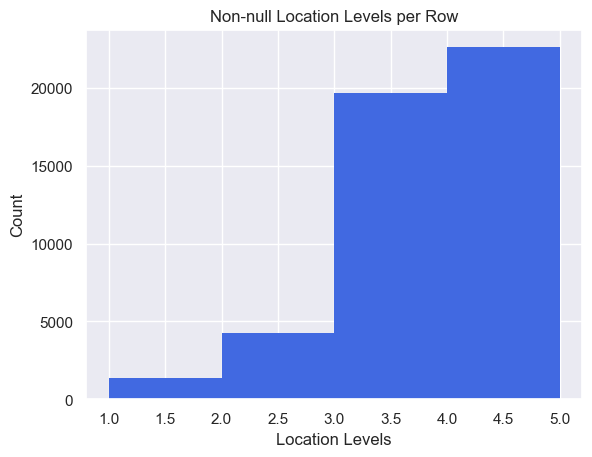

In [99]:
LOCATION_DEPTH_BINS = np.arange(1.0, 5.5, 1.0).tolist()

plt.hist(
    location_depth["distribution"],
    bins=LOCATION_DEPTH_BINS,
    color=PRIMARY_COLOR,
)
plt.title("Non-null Location Levels per Row")
plt.xlabel("Location Levels")
plt.ylabel("Count")
plt.show()


### Interpretation: Location Depth
- Rows are relatively rich in hierarchy: mean depth is **3.241**, median is 3, and p90 is 4.
- This indicates most rows provide multi-level geographic detail.
- Depth-based features (e.g., granularity level) are feasible for modeling.


### Location rows per movie


In [100]:
location_rows_per_movie = rows_per_movie_location_report(movie_locations_df)

print("Location rows per movie summary:")
display(location_rows_per_movie["summary"])
print("Top movies by location rows:")
display(location_rows_per_movie["top_movies"])


Location rows per movie summary:


,metric,value
0,movies_with_locations,10197.000
1,mean,4.822
2,median,3.000
3,p90,11.000
4,p95,15.000
5,p99,26.000
6,max,87.000


Top movies by location rows:


,rows_per_movie
movieID,
3082,87
5872,84
3638,83
5796,75
49272,75
2990,70
2991,68
6299,68
10,68


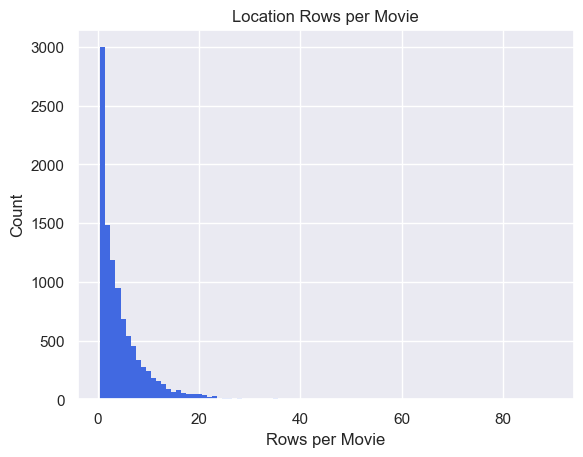

In [101]:
LOCATION_ROWS_PER_MOVIE_BINS = np.arange(0.5, 90.5, 1.0).tolist()

plt.hist(
    location_rows_per_movie["distribution"],
    bins=LOCATION_ROWS_PER_MOVIE_BINS,
    color=PRIMARY_COLOR,
)
plt.title("Location Rows per Movie")
plt.xlabel("Rows per Movie")
plt.ylabel("Count")
plt.show()


### Interpretation: Location Rows per Movie
- Location row density is long-tail: mean 4.822, median 3, p90 11, p99 26, max 87.
- Some movies have very dense location metadata, which can dominate naive count features.
- Recommended: use log-scaling or capped counts for location-volume features.


### Section 9 Summary
- `movie_locations` has full movie coverage and no duplicate key tuples.
- Missingness is primarily structural in deeper hierarchy fields, not random corruption.
- The table is feature-rich but highly skewed by movie-level row volume; robust aggregation is recommended.


## 10. Detailed EDA: `tags`


### Goal
Assess tag lookup quality, cross-table ID coverage, and tag usage skew across movie and user tagging events.


In [102]:
tags_df = data["tags"]
movie_tags_df = data["movie_tags"]
user_taggedmovies_df = data["user_taggedmovies"]

tags_overview = dataframe_overview(tags_df)
display(tags_overview)


,column,dtype,type_group,missing_count,missing_pct,n_unique,mean,std,min,max
0,id,int64,id-like,0,0.0,13222,None,None,None,None
1,value,object,non-numeric,0,0.0,13222,None,None,None,None


### Interpretation: Overview of `tags`
- `tags` has 13,222 rows and 2 columns (`id`, `value`).
- There are no missing values and no duplicate rows.
- `id` and `value` are both unique, so this is a clean lookup table.


### Suspicious Tags


In [103]:
suspicious_tags = suspicious_tag_report(tags_df)

print("Suspicious Tag Report Summary:")
display(suspicious_tags["summary"])

print("\nSuspicious Tag Report Details:")
display(suspicious_tags["suspicious_rows"])


Suspicious Tag Report Summary:


,metric,value
0,rows_total,13222
1,missing_tag_value,0
2,empty_or_whitespace_tag_value,0
3,one_character_tag_value,0
4,numeric_only_tag_value,0
5,suspicious_rows_total,0



Suspicious Tag Report Details:


,id,value,reason


### Interpretation: Suspicious Tags
- Suspicious rows total is **0**: no missing, empty, one-character, or numeric-only tag values.
- Tag labels are clean and can be used directly in lookup joins and analyses.


In [104]:
tags_coverage = tags_coverage_report(tags_df, movie_tags_df, user_taggedmovies_df)
print("Tag ID coverage summary:")
display(tags_coverage)


Tag ID coverage summary:


,metric,value
0,tags_total,13222.0
1,movie_tag_ids_total,5297.0
2,user_tag_ids_total,9079.0
3,movie_tag_coverage_pct,100.0
4,user_tag_coverage_pct,100.0
5,unused_tags_in_lookup,3281.0


### Interpretation: Tag ID Coverage
- Tag ID coverage is complete in both event tables: movie tags 100.0%, user tags 100.0%.
- There are 3,281 unused tags in the lookup table (defined but not observed in these two event tables).
- This is common in open vocabularies and should not be treated as integrity failure.


### Tag usage distribution


In [105]:
tag_usage = tag_usage_report(tags_df, movie_tags_df, user_taggedmovies_df)

print("Tag usage summary:")
display(tag_usage["summary"])
print("Top tags by total usage:")
display(tag_usage["top_tags"])


Tag usage summary:


,metric,value
0,used_tags_total,9941.000
1,mean,10.034
2,median,2.000
3,p90,18.000
4,p95,38.000
5,p99,152.200
6,max,1280.000


Top tags by total usage:


,movie_tag_count,user_tag_count,total_usage,tag_value
tagID,,,,
6800,640,640,1280,tumeys dvds
1925,403,402,805,erlends dvds
93,341,406,747,nudity (topless)
605,268,454,722,classic
1061,369,201,570,based on a book
587,283,285,568,bibliothek
1224,263,261,524,adapted from:book
398,491,17,508,less than 300 ratings
651,249,231,480,seen more than once


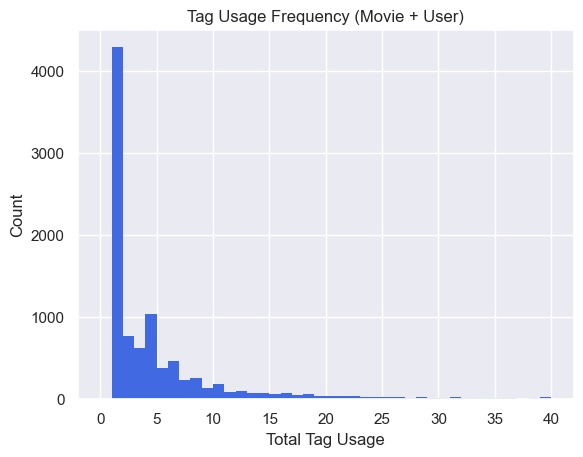

In [106]:
TAG_USAGE_BINS = np.r_[np.arange(0, 41, 1)]

plt.hist(
    tag_usage["distribution"],
    bins=TAG_USAGE_BINS,
    color=PRIMARY_COLOR,
)
plt.title("Tag Usage Frequency (Movie + User)")
plt.xlabel("Total Tag Usage")
plt.ylabel("Count")
plt.show()


### Interpretation: Tag Usage
- Usage is strongly long-tail: median 2, p90 18, p99 152.2, max 1,280.
- Most tags are rare, while a small set is used very frequently.
- For modeling, consider minimum-frequency filtering or smoothing for sparse tail tags.


### Section 10 Summary
- `tags` lookup quality is excellent (no missing/no duplicates; unique IDs and values).
- Referential coverage of used tag IDs is complete across movie and user tagging tables.
- Tag usage is highly skewed, so robust handling of rare tags is recommended in feature engineering.


## 11. Detailed EDA: `movie_tags`


### Goal
Assess movie-tag assignment quality, coverage consistency, and tag-weight distribution behavior.


In [107]:
movie_tags_df = data["movie_tags"]
movies_df = data["movies"]
tags_df = data["tags"]

movie_tags_overview = dataframe_overview(movie_tags_df)
display(movie_tags_overview)


,column,dtype,type_group,missing_count,missing_pct,n_unique,mean,std,min,max
0,movieID,int64,id-like,0,0.0,7155,NaN,NaN,NaN,NaN
1,tagID,int64,id-like,0,0.0,5297,NaN,NaN,NaN,NaN
2,tagWeight,int64,numeric,0,0.0,30,1.381156,1.279396,1.0,42.0


### Interpretation: Overview of `movie_tags`
- `movie_tags` contains 51,795 rows and 3 columns (`movieID`, `tagID`, `tagWeight`).
- By dataset definition, `tagWeight` is the number of times a tag was assigned to a movie.
- There are no missing values and no duplicate `movieID + tagID` pairs, so each row is a unique aggregated movie-tag count.


### Suspicious Records


In [108]:
suspicious_movie_tags = suspicious_movie_tags_report(movie_tags_df)

print("Suspicious Movie Tags Summary:")
display(suspicious_movie_tags["summary"])

print("\nSuspicious Movie Tags Details:")
display(suspicious_movie_tags["suspicious_rows"])


Suspicious Movie Tags Summary:


,metric,value
0,rows_total,51795
1,missing_tag_weight,0
2,non_positive_tag_weight,0
3,non_integer_tag_weight,0
4,suspicious_rows_total,0
5,duplicate_movie_tag_pairs,0



Suspicious Movie Tags Details:


,movieID,tagID,tagWeight,reason


### Interpretation: Suspicious Records
- Quality checks show 0 suspicious rows for `tagWeight` (no missing, non-positive, or non-integer values).
- Duplicate `movieID + tagID` pairs are also 0, which is consistent with one aggregated count per pair.
- Conclusion: the table is structurally clean for count-based tag features.


In [109]:
movie_tags_coverage = movie_tags_coverage_report(movie_tags_df, movies_df, tags_df)
print("Movie tags coverage summary:")
display(movie_tags_coverage)


Movie tags coverage summary:


,metric,value
0,rows_total,51795.0
1,unique_movies_in_movie_tags,7155.0
2,unique_tags_in_movie_tags,5297.0
3,movie_id_coverage_pct,100.0
4,tag_id_coverage_pct,100.0


### Interpretation: Coverage
- Referential coverage is complete: `movieID` coverage is 100.0% and `tagID` coverage is 100.0%.
- `movie_tags` covers 7,155 movies and 5,297 distinct tags.
- This confirms all movie/tag references in this table are valid against lookup tables.


### Tag weight distribution


In [110]:
tag_weight = tag_weight_report(movie_tags_df)

print("Tag weight summary:")
display(tag_weight["summary"])


Tag weight summary:


,metric,value
0,count,51795.000
1,mean,1.381
2,median,1.000
3,p90,2.000
4,p95,3.000
5,p99,7.000
6,max,42.000


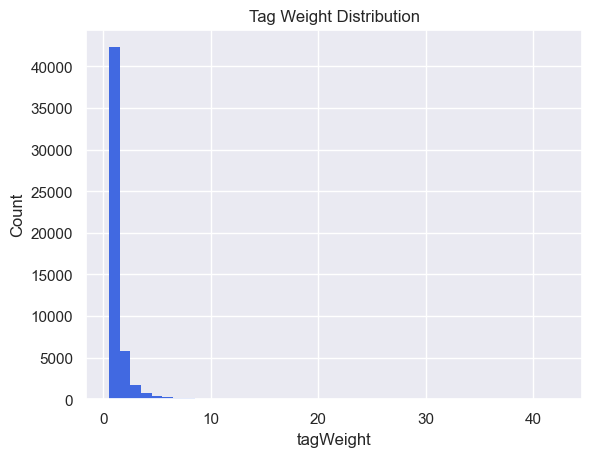

In [111]:
TAG_WEIGHT_BINS = np.arange(0.5, 42.6, 1.0)

plt.hist(
    tag_weight["distribution"],
    bins=TAG_WEIGHT_BINS,
    color=PRIMARY_COLOR,
)
plt.title("Tag Weight Distribution")
plt.xlabel("tagWeight")
plt.ylabel("Count")
plt.show()


### Interpretation: Tag Weight
- `tagWeight` behaves like a count variable (median 1, p90 2, p99 7, max 42).
- Most movie-tag pairs are assigned only a few times, while a small fraction has high assignment counts.


### Tags per movie and movies per tag


In [112]:
tags_per_movie = tags_per_movie_report(movie_tags_df)
movies_per_tag = movies_per_tag_report(movie_tags_df, tags_df)

print("Tags per movie summary:")
display(tags_per_movie["summary"])
print("Movies per tag summary:")
display(movies_per_tag["summary"])
print("Top tags by movies count:")
display(movies_per_tag["top_tags"])


Tags per movie summary:


,metric,value
0,movies_with_tags,7155.000
1,mean,7.239
2,median,4.000
3,p90,18.000
4,p95,26.000
5,p99,48.460
6,max,107.000


Movies per tag summary:


,metric,value
0,used_tags_total,5297.000
1,mean,9.778
2,median,3.000
3,p90,19.000
4,p95,36.000
5,p99,96.040
6,max,640.000


Top tags by movies count:


,movies_per_tag,tag_value
tagID,,
6800,640,tumeys dvds
398,491,less than 300 ratings
1925,403,erlends dvds
887,370,70mm
1061,369,based on a book
93,341,nudity (topless)
2136,328,movie to see
6535,290,national film registry
6898,290,betamax


### Interpretation: Assignment Density
- Tag assignments are sparse and long-tail in both directions.
- Per-movie: median 4 tags, p90 18, p99 ~48.46, max 107.
- Per-tag: median 3 movies, p90 19, p99 ~96.04, max 640.


### Section 11 Summary
- `movie_tags` is high-quality and fully referentially consistent with `movies` and `tags`.
- `tagWeight` is an aggregated assignment count per `(movieID, tagID)` pair, not a normalized score.
- Distributions are strongly skewed, so count-based features should use robust scaling/capping in feature engineering.
